# Bias and Variance Tradeoff - Overfitting

2025-06-16 ug V1.6

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Erzeugung von Daten (X,y) 
Die hier erzeugten Daten (X, y) weisen einen nichtlinearen Zusammenhang auf.

Wir wählen einen störungsfreien, deterministischen und nichtlinearen Zusammenhang zwischen dem Eingang $X$ und Ausgang $y_{org}$ :

$
y_{org}(X) = 6 \cdot \sin{\left(\frac{\pi \cdot X}{2*8}\right)}
$

Am Ausgang $y$ überlagern wir eine normalverteilte und mit dem Ausgang $y_{org}$ unkorrelierte Störung $\epsilon_{org}$.

$
y(X) = y_{org}(X) + \epsilon 
$

mit  $\epsilon_{org} \sim \mathcal{N}(\mu,\,\sigma^{2})$, Erwartungswert $\mu=0$ (mittelwertfrei) und konstanter Varianz $\sigma^2=1$.


In [2]:
N=17                                              # Anzahl der Datenpunkte
x_max = 8                                         # maximaler Wert für den Eingang
np.random.seed(42)                                # Initialisieren des Zufallgenerators
x_org = np.linspace(0,x_max,N)                    # Eingang mit gleiche Abständnen im Bereich 0 und x_max
y_org_nominal = 6.0 * np.sin(x_org/x_max*np.pi/2) # ungestörter Ausgang
epsilon_org = 0.5*np.random.randn(N)              # Störung
y_org = y_org_nominal + epsilon_org               # Störung dem Ausgang überlagern
X = x_org.reshape((-1,1))                         # X als Matrix anlegen
y = y_org                                         # Ausgang

In [3]:
X,y

(array([[0. ],
        [0.5],
        [1. ],
        [1.5],
        [2. ],
        [2.5],
        [3. ],
        [3.5],
        [4. ],
        [4.5],
        [5. ],
        [5.5],
        [6. ],
        [6.5],
        [7. ],
        [7.5],
        [8. ]]),
 array([0.24835708, 0.51897069, 1.4943862 , 2.50322299, 2.17902391,
        2.71131194, 4.12302781, 4.19007707, 4.00790349, 4.90934274,
        4.75710883, 5.05866271, 5.66425833, 4.78500189, 5.02225277,
        5.6899646 , 5.49358444]))

**Anmerkung:** In der Praxis gibt es meist mehrere Eingänge und nicht wie hier nur einen Eingang. Deshalb ist die X als 2-dimensionale Array (Matrix) angelegt. 

----
### Plotten der Daten

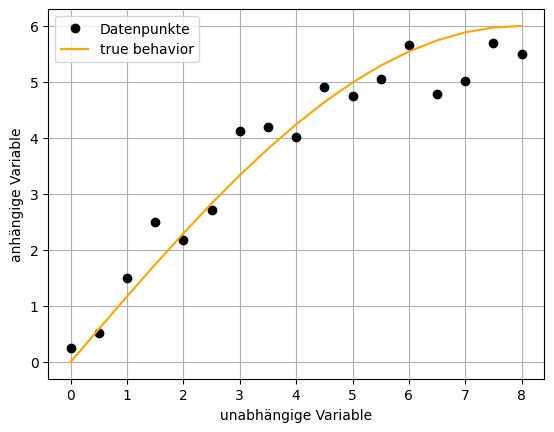

In [4]:
plt.plot(X, y,marker = 'o',ls='None',label='Datenpunkte',color='black')
plt.plot(x_org, y_org_nominal,label='true behavior',color='orange')
plt.xlabel('unabhängige Variable')
plt.ylabel('anhängige Variable')
plt.grid(True)
plt.legend();

---
### Aufteilen der Daten in einen Trainings- und einen Testdatensatz

Dazu stellt scikit-learn die Funktion 
[`sklearn.model_selection.train_test_split()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
bereit. 


In [ ]:
#from sklearn.model_selection import train_test_split
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

Zur besseren grafischen Visualisierung verwenden wir hier aber einen einfacheren Ansatz:
Trainingsdaten wechseln sich mit Testdaten ab.

In [5]:
X_train, X_test, y_train, y_test = X[::2],X[1::2], y[::2],y[1::2]

In [6]:
X_train.shape, X_test.shape

((9, 1), (8, 1))

Plotten des Trainings und Testdatensatzes:

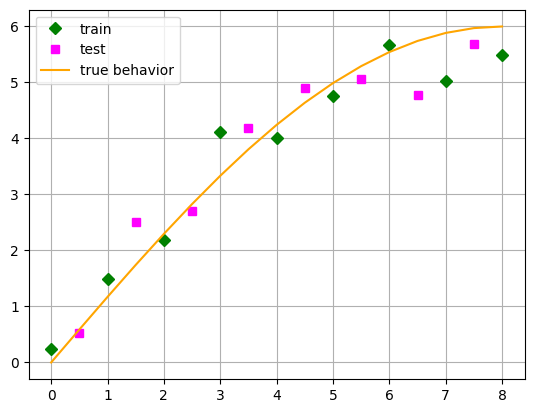

In [7]:
plt.plot(X_train, y_train,marker = 'D',ls='None', label='train', color='green')
plt.plot(X_test, y_test,marker = 's',ls='None',label='test',color='magenta')
plt.plot(x_org, y_org_nominal,label='true behavior',color='orange')
plt.legend()
plt.grid(True)

---
## Lineare Regression

Modellannahme bei der Linearen Regression:
$
y_i(x_i) = \beta_0 + \beta_1 x_i + \epsilon_i
$

mit $i=0 .. N-1$
- $\beta_0$ - wahrer Achsenabschnitt (true intercept)
- $\beta_1$ - wahre Steigung (true slope)
- $\epsilon_i$ - Störung unkorreliert und normalverteilt $\sim \mathcal{N}(\mu,\,\sigma^{2})$ mit Erwartungswert $\mu=0$ (mittelwertfrei) und konstanter Varianz $\sigma^2$

Prädiktions-Modell bzw. Schätzer:
$
\hat{y}_i(x_i) = \hat{\beta}_0 + \hat{\beta}_1 x_i
$
mit den Modellparametern:
- $\hat{\beta}_0$ - geschätzter Achsenabschnitt (estimated intercept)
- $\hat{\beta}_1$ - geschätzte Steigung (estimated slope)

Mit Hilfe der Klasse 
[`sklearn.linear_model.LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
- bestimmen wir die Modellparameter $\hat{\beta}_0$ und $\hat{\beta}_1$ und 
- bestimmen wir die Leistungsfähigkeit des Prädiktions-Modells mittels des Bestimmungsmass (coefficient of determination) **$R^2$**:

Das Bestimmungsmass (coefficient of determination) **$R^2$** ermitteln wir mittels folgender Methoden/Funktionen:
   - [`score(X, y)`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.score)
   - [`metrics.r2_score(y,y_hat)`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html)



In [8]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

Anpassen der Modellparameter der Linearen Regression $\hat{\beta}_0$ und $\hat{\beta}_1$ durch den Trainingsdatensatz:

In [9]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Ausgabe der geschätzen Modellparameter:

In [10]:
print(f"geschätzte Steigung (estimated slope)            : {lr_model.coef_[0]:.3f}")
print(f"geschätzter Achsenabschnitt (estimated intercept): {lr_model.intercept_:.3f}")

geschätzte Steigung (estimated slope)            : 0.653
geschätzter Achsenabschnitt (estimated intercept): 1.054


Bestimmung der Leistungsfähigkeit der Methode [`score(X, y)`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.score)

In [11]:
print(f"R_squared: {lr_model.score(X_train, y_train):.3f}")

R_squared: 0.873


#### Bestimmungsmass/Determinationskoeffizient $R^2$

Kennzahl zur Beurteilung der Anpassungsgüte einer Regression 
[Bestimmungsmass-Wikipedia](https://de.wikipedia.org/wiki/Bestimmtheitsma%C3%9F)

Das Bestimmungsmass $R^2$ gibt an, wie viel Streuung in den Daten durch ein vorliegendes lineares Regressionsmodell „erklärt“ werden kann.

Interpretation:

Das Bestimmtheitsmaß lässt sich mit 100 % multiplizieren, um es in Prozent anzugeben: 100 % $R^2$ ist dann der prozentuale Anteil der Streuung in $y$ der durch das lineare Modell „erklärt“ wird, und liegt daher zwischen:
-   0 % (oder 0): schlechtes Modell und
- 100 % (oder 1): perfektes Modell.

[`sklearn.metrics.r2_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html)

Prädiktion des Traingsdatensatzes


In [12]:
y_pred_LinearRegression_train = lr_model.predict(X_train)
y_pred_LinearRegression_train

array([1.05427416, 1.70709181, 2.35990946, 3.01272711, 3.66554476,
       4.31836241, 4.97118006, 5.62399771, 6.27681536])

In [13]:
R_squared = metrics.r2_score(y_train,y_pred_LinearRegression_train)
R_squared

0.8728210791733721

Mean Squared Error
$
\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$

[`sklearn.metrics.mean_squared_error()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html)

In [14]:
MSE = metrics.mean_squared_error(y_train, y_pred_LinearRegression_train)
MSE

0.41398292255646496

#### Plot der Prädiktion

In [15]:
# Linie des Prädiktionsmodells erzeugen
X_plot = np.linspace(0,x_max,200).reshape(-1,1)
y_plot_pred_LinearRegression_train = lr_model.predict(X_plot)

für die Trainingsdaten

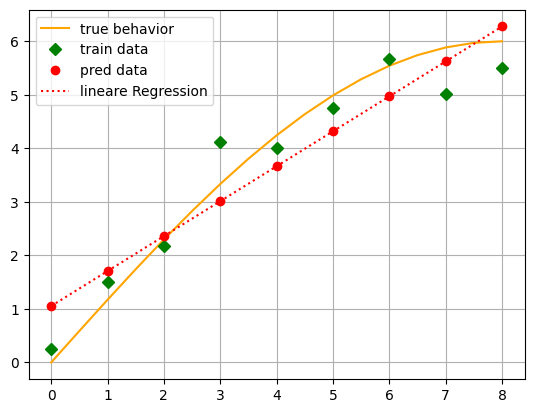

In [16]:
plt.plot(x_org, y_org_nominal,label='true behavior',color='orange')
plt.plot(X_train, y_train, marker = 'D',ls='None', label='train data',color='green')
plt.plot(X_train, y_pred_LinearRegression_train,marker = 'o',ls='None',label='pred data',color='red')
plt.plot(X_plot, y_plot_pred_LinearRegression_train,label='lineare Regression',linestyle=':',color='red')

plt.legend()
plt.grid(True)

für den Testdatensatz

In [17]:
print(f"R_squared: {lr_model.score(X_test, y_test):.3f}")

R_squared: 0.857


In [18]:
y_pred_LinearRegression_test = lr_model.predict(X_test)
y_pred_LinearRegression_test

array([1.38068298, 2.03350064, 2.68631829, 3.33913594, 3.99195359,
       4.64477124, 5.29758889, 5.95040654])

In [19]:
R_squared = metrics.r2_score(y_test,y_pred_LinearRegression_test)
R_squared

0.8566112874284983

In [20]:
MSE = metrics.mean_squared_error(y_test, y_pred_LinearRegression_test)
MSE

0.37892463895359474

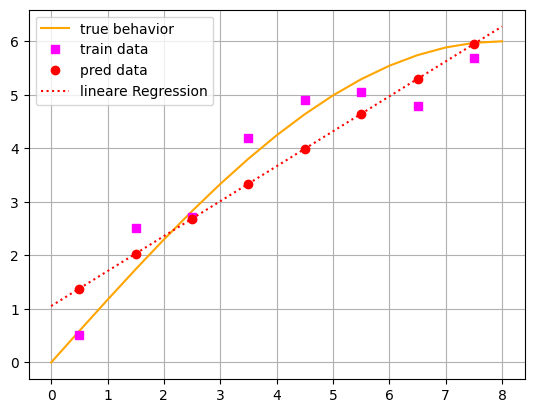

In [21]:
plt.plot(x_org, y_org_nominal,label='true behavior',color='orange')
#plt.plot(X_train, y_train, marker = 'D',ls='None', label='train data',color='green')
plt.plot(X_test, y_test, marker = 's',ls='None', label='train data',color='magenta')
plt.plot(X_test, y_pred_LinearRegression_test,marker = 'o',ls='None',label='pred data',color='red')
plt.plot(X_plot, y_plot_pred_LinearRegression_train,label='lineare Regression',linestyle=':',color='red')
plt.legend()
plt.grid(True)

---
## Polynomial Regression

$
y_i(x_i) = \beta_0 + \beta_1 x_i + \beta_2 x_i^2 + \beta_3 x_i^3 + ...  + \beta_p x_i^p + \epsilon_i
$

mit $i=0 .. N-1$ und $p$ Polynomgrad
- Parametern $\beta_0$, $\beta_1$, $\beta_2$, $\beta_3$ .. , $\beta_p$ 
- $\epsilon_i$ - unkorreliert und normalverteilt $\sim \mathcal{N}(\mu,\,\sigma^{2})$ mit Erwartungswert $\mu=0$ (mittelwertfrei) und konstanter Varianz $\sigma^2$

Präditionsmodell bzw. Schätzer:

$
\hat{y}_i(x_i) = \hat{\beta}_0 + \hat{\beta}_1 x_i + \hat{\beta}_2 x_i^2 + \hat{\beta}_3 x_i^3 + ...  + \hat{\beta}_p x_i^p 
$
und den Modellparametern:
- $\hat{\beta}_0$, $\hat{\beta}_1$, $\hat{\beta}_2$, $\hat{\beta}_3$ und $\hat{\beta}_p$ 



Ist immer noch eine "lineare Regression", weil die zu schätzenden Parameter $\beta_0$, $\beta_1$, $\beta_2$, $\beta_3$ .. , $\beta_p$ linear in das Modell eingehen.

Aufbau der Features mit der Klasse [`sklearn.preprocessing.PolynomialFeatures()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)


In [22]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

Datensatz für lineare Regression der Polynomkoeffizienten aufbauen

In [23]:
X_train

array([[0.],
       [1.],
       [2.],
       [3.],
       [4.],
       [5.],
       [6.],
       [7.],
       [8.]])

In [24]:
X_train.shape

(9, 1)

 ### Polynom 8ten Grades
 Wir wählen ein Polynom 8ten Grades:

In [25]:
pre_process_poly8 = PolynomialFeatures(degree=8,include_bias=False)

X_train_poly8 = pre_process_poly8.fit_transform(X_train)
X_train_poly8

array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
       [1.0000000e+00, 1.0000000e+00, 1.0000000e+00, 1.0000000e+00,
        1.0000000e+00, 1.0000000e+00, 1.0000000e+00, 1.0000000e+00],
       [2.0000000e+00, 4.0000000e+00, 8.0000000e+00, 1.6000000e+01,
        3.2000000e+01, 6.4000000e+01, 1.2800000e+02, 2.5600000e+02],
       [3.0000000e+00, 9.0000000e+00, 2.7000000e+01, 8.1000000e+01,
        2.4300000e+02, 7.2900000e+02, 2.1870000e+03, 6.5610000e+03],
       [4.0000000e+00, 1.6000000e+01, 6.4000000e+01, 2.5600000e+02,
        1.0240000e+03, 4.0960000e+03, 1.6384000e+04, 6.5536000e+04],
       [5.0000000e+00, 2.5000000e+01, 1.2500000e+02, 6.2500000e+02,
        3.1250000e+03, 1.5625000e+04, 7.8125000e+04, 3.9062500e+05],
       [6.0000000e+00, 3.6000000e+01, 2.1600000e+02, 1.2960000e+03,
        7.7760000e+03, 4.6656000e+04, 2.7993600e+05, 1.6796160e+06],
       [7.0000000e+00, 4.9000000e+01, 3.4

In [26]:
X_train_poly8.shape

(9, 8)

Objekt für Berechnung der Lineare Regression erstellen

In [27]:
pr_model_poly8 = LinearRegression()

Modell an die Daten anpassen

In [28]:
pr_model_poly8.fit(X_train_poly8, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
pr_model_poly8.intercept_, pr_model_poly8.coef_ 

(np.float64(0.24835699126630573),
 array([ 1.94980631e+01, -4.22936469e+01,  3.65977795e+01, -1.58992115e+01,
         3.82487352e+00, -5.17664444e-01,  3.69150364e-02, -1.07920818e-03]))

Prädiktion

In [30]:
y_poly8_pred_train = pr_model_poly8.predict(X_train_poly8)

Bestimmtheitsmass $R^2$

Modell passt perfekt zu den angefitteten Daten

In [31]:
R_squared_poly8 = metrics.r2_score(y_train,y_poly8_pred_train)
R_squared_poly8

0.9999999999999991

-> **Perfekt!**

Mean Squared Error 

ist auch extrem klein

In [32]:
MSE = metrics.mean_squared_error(y_train, y_poly8_pred_train)
MSE

3.0223729450354712e-15

#### Plot der Prädiktion

für den Trainingsdatensatz

In [33]:
X_plot_train_poly = pre_process_poly8.fit_transform(X_plot)
y_plot_pred_PolyRegression_train = pr_model_poly8.predict(X_plot_train_poly)

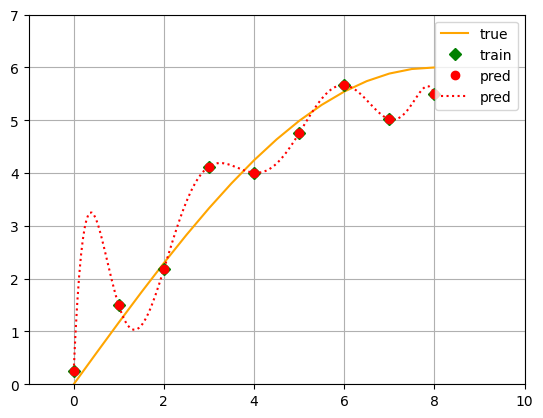

In [34]:
plt.plot(x_org, y_org_nominal,label='true',color='orange')
plt.plot(X_train, y_train, marker = 'D',ls='None', label='train',color='green')
plt.plot(X_train, y_poly8_pred_train,marker = 'o',ls='None',label='pred',color='red')
plt.plot(X_plot, y_plot_pred_PolyRegression_train,label='pred',color='red',linestyle=':')

plt.legend()
plt.ylim(0,7)
plt.xlim(-1,10)
plt.grid(True)




für den Testdatensatz

In [35]:
X_test_poly8 = pre_process_poly8.fit_transform(X_test)
X_test_poly8

array([[5.00000000e-01, 2.50000000e-01, 1.25000000e-01, 6.25000000e-02,
        3.12500000e-02, 1.56250000e-02, 7.81250000e-03, 3.90625000e-03],
       [1.50000000e+00, 2.25000000e+00, 3.37500000e+00, 5.06250000e+00,
        7.59375000e+00, 1.13906250e+01, 1.70859375e+01, 2.56289062e+01],
       [2.50000000e+00, 6.25000000e+00, 1.56250000e+01, 3.90625000e+01,
        9.76562500e+01, 2.44140625e+02, 6.10351562e+02, 1.52587891e+03],
       [3.50000000e+00, 1.22500000e+01, 4.28750000e+01, 1.50062500e+02,
        5.25218750e+02, 1.83826562e+03, 6.43392969e+03, 2.25187539e+04],
       [4.50000000e+00, 2.02500000e+01, 9.11250000e+01, 4.10062500e+02,
        1.84528125e+03, 8.30376562e+03, 3.73669453e+04, 1.68151254e+05],
       [5.50000000e+00, 3.02500000e+01, 1.66375000e+02, 9.15062500e+02,
        5.03284375e+03, 2.76806406e+04, 1.52243523e+05, 8.37339379e+05],
       [6.50000000e+00, 4.22500000e+01, 2.74625000e+02, 1.78506250e+03,
        1.16029062e+04, 7.54188906e+04, 4.90222789e+05, 3.

In [36]:
print(f"R_squared: {pr_model_poly8.score(X_test_poly8, y_test):.3f}")

R_squared: 0.508


In [37]:
y_pred_poly8_test = pr_model_poly8.predict(X_test_poly8)
y_pred_poly8_test

array([3.11672151, 1.11417476, 3.45987161, 4.14564095, 4.18065993,
       5.40731312, 5.38022351, 5.30554316])

In [38]:
R_squared = metrics.r2_score(y_test,y_pred_poly8_test)
R_squared

0.5083189624587335

In [39]:
MSE = metrics.mean_squared_error(y_test, y_pred_poly8_test)
MSE

1.2993356052189162

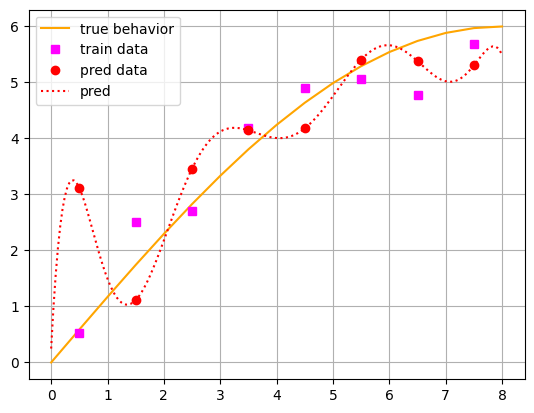

In [40]:
plt.plot(x_org, y_org_nominal,label='true behavior',color='orange')
#plt.plot(X_train, y_train, marker = 'D',ls='None', label='train data',color='green')
plt.plot(X_test, y_test, marker = 's',ls='None', label='train data',color='magenta')
plt.plot(X_test, y_pred_poly8_test,marker = 'o',ls='None',label='pred data',color='red')
plt.plot(X_plot, y_plot_pred_PolyRegression_train,label='pred',color='red',linestyle=':')
plt.legend()
plt.grid(True)

## Schleife über Polynome 1 bis 8 Ordnung

In [41]:
Liste_Ordnung   = []
Liste_MSE_train = []
Liste_MSE_test  = []

for Ordnung in range(1,9):
    print(f"Polynom {Ordnung}-ter Ordnung")
    
    # Feature erzeugen 
    pre_process_poly = PolynomialFeatures(degree=Ordnung,include_bias=False)
    X_train_poly = pre_process_poly.fit_transform(X_train)
    X_test_poly  = pre_process_poly.fit_transform(X_test)
    
    # Polynomial Regression
    pr_model = LinearRegression()
    pr_model.fit(X_train_poly, y_train)
    
    # Prädiktion mit Trainingsdaten
    y_poly_pred_train = pr_model.predict(X_train_poly)
    
    # Prädiktion mit Testdaten
    y_poly_pred_test = pr_model.predict(X_test_poly)
    
    # Mean Square Error für Trainings und Testdaten
    MSE_train = metrics.mean_squared_error(y_train, y_poly_pred_train)
    MSE_test  = metrics.mean_squared_error(y_test, y_poly_pred_test)

    Liste_Ordnung.append(Ordnung)
    Liste_MSE_train.append(MSE_train)
    Liste_MSE_test.append(MSE_test)


Polynom 1-ter Ordnung
Polynom 2-ter Ordnung
Polynom 3-ter Ordnung
Polynom 4-ter Ordnung
Polynom 5-ter Ordnung
Polynom 6-ter Ordnung
Polynom 7-ter Ordnung
Polynom 8-ter Ordnung


In [42]:
data = {'MSE_train': Liste_MSE_train, 'MSE_test': Liste_MSE_test}
df_MSE = pd.DataFrame(data=data,index=Liste_Ordnung)
df_MSE

,MSE_train,MSE_test
1,4.139829e-01,0.378925
2,1.072642e-01,0.122832
3,1.066825e-01,0.127361
4,1.018563e-01,0.117465
5,1.010681e-01,0.118545
6,9.090259e-02,0.163148
7,1.634671e-02,0.906082
8,3.022373e-15,1.299336


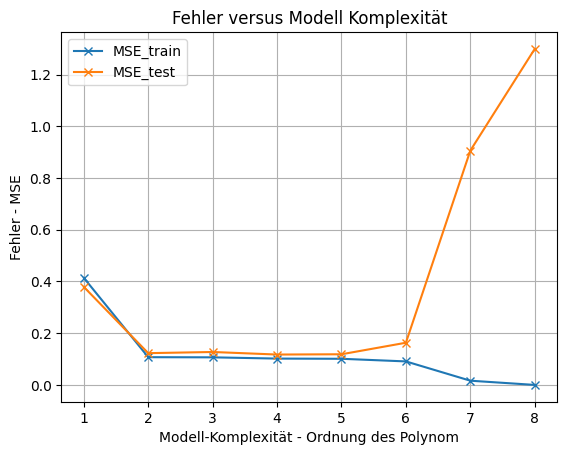

In [43]:
fig, ax = plt.subplots()
df_MSE.plot(ax=ax,marker='x');
ax.grid(True)
ax.set_xlabel('Modell-Komplexität - Ordnung des Polynom')
ax.set_ylabel('Fehler - MSE')
ax.set_title('Fehler versus Modell Komplexität');

Interpretation des Diagramms:
<br>
- Vom linearem Modell erster Ordnung zum Polynom zweiter Ordnung gibt es eine deutliche Verbesserung von ca. 0.4 bis 0.12.
- Dann gibt es vom Polynom 2ter Ordnung bis zum Polynom 5ter einen sehr flachen Verlauf des Fehlers (Plateau).
- Ab dem Polynom 6ter Ordnung steigt der Fehler mit dem Test-Datensatz deulich an. Hier beginnt das _**Overfitting**_.
Der Fehler mit dem Test-Datensatz wird immer kleiner und der Fehler mit dem Test-Datensatz steigt stark an.

In der Praxis wird ein _**Modell mit Polynom 2ter Ordnung**_ verwendet werden, weil es am Anfang des Plateau liegt.
<br>
Im folgenden werden wir uns das Modell mit Polynom 2ter Ordnung näher ansehen:

 ### Polynom 2ten Grades
 Wir wählen ein Polynom 2ten Grades:

In [44]:
pre_process_poly2 = PolynomialFeatures(degree=2,include_bias=False)

X_train_poly2 = pre_process_poly2.fit_transform(X_train)
X_train_poly2

array([[ 0.,  0.],
       [ 1.,  1.],
       [ 2.,  4.],
       [ 3.,  9.],
       [ 4., 16.],
       [ 5., 25.],
       [ 6., 36.],
       [ 7., 49.],
       [ 8., 64.]])

In [45]:
X_train_poly2.shape

(9, 2)

Objekt für Berechnung der Lineare Regression erstellen

In [46]:
pr_model_poly2 = LinearRegression()

Modell an die Daten anpassen

In [47]:
pr_model_poly2.fit(X_train_poly2, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [48]:
pr_model_poly2.intercept_, pr_model_poly2.coef_ 

(np.float64(0.17068006562001203), array([ 1.41018402, -0.0946708 ]))

Prädiktion

In [49]:
y_poly2_pred_train = pr_model_poly2.predict(X_train_poly2)

Bestimmtheitsmass $R^2$

Modell passt perfekt zu den angefitteten Daten

In [50]:
R_squared_poly2 = metrics.r2_score(y_train,y_poly2_pred_train)
R_squared_poly2

0.9670475601327673

-> **sehr gut!**

Mean Squared Error 

ist auch extrem klein

In [51]:
MSE = metrics.mean_squared_error(y_train, y_poly2_pred_train)
MSE

0.10726421700180806

#### Plot der Prädiktion

für den Traingsdatensatz

In [52]:
X_plot_train_poly = pre_process_poly2.fit_transform(X_plot)
y_plot_pred_PolyRegression_train = pr_model_poly2.predict(X_plot_train_poly)

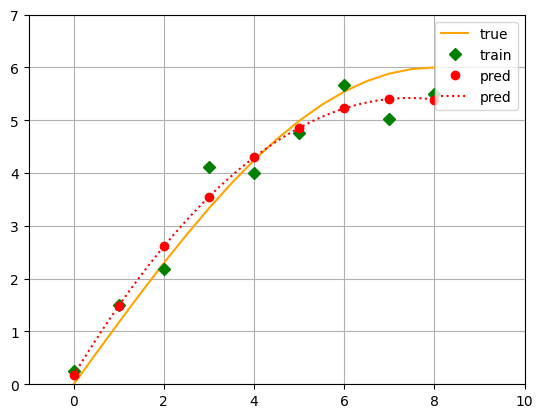

In [53]:
plt.plot(x_org, y_org_nominal,label='true',color='orange')
plt.plot(X_train, y_train, marker = 'D',ls='None', label='train',color='green')
plt.plot(X_train, y_poly2_pred_train,marker = 'o',ls='None',label='pred',color='red')
plt.plot(X_plot, y_plot_pred_PolyRegression_train,label='pred',color='red',linestyle=':')

plt.legend()
plt.ylim(0,7)
plt.xlim(-1,10)
plt.grid(True)

für den Testdatensatz

In [54]:
X_test_poly2 = pre_process_poly2.fit_transform(X_test)
X_test_poly2

array([[ 0.5 ,  0.25],
       [ 1.5 ,  2.25],
       [ 2.5 ,  6.25],
       [ 3.5 , 12.25],
       [ 4.5 , 20.25],
       [ 5.5 , 30.25],
       [ 6.5 , 42.25],
       [ 7.5 , 56.25]])

In [55]:
print(f"R_squared: {pr_model_poly2.score(X_test_poly2, y_test):.3f}")

R_squared: 0.954


In [56]:
y_pred_poly2_test = pr_model_poly2.predict(X_test_poly2)
y_pred_poly2_test

array([0.85210438, 2.0729468 , 3.10444763, 3.94660688, 4.59942453,
       5.06290058, 5.33703505, 5.42182793])

In [57]:
R_squared = metrics.r2_score(y_test,y_pred_poly2_test)
R_squared

0.9535192798261278

In [58]:
MSE = metrics.mean_squared_error(y_test, y_pred_poly2_test)
MSE

0.12283177520967624

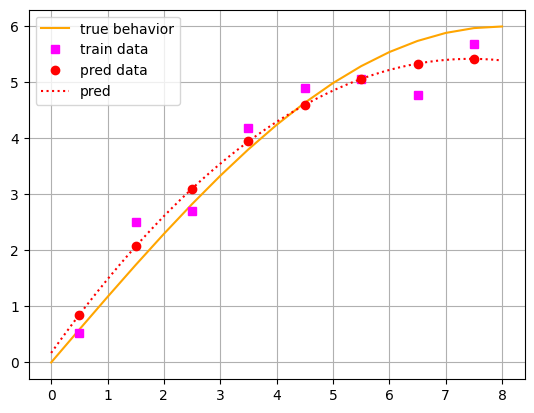

In [59]:
plt.plot(x_org, y_org_nominal,label='true behavior',color='orange')
#plt.plot(X_train, y_train, marker = 'D',ls='None', label='train data',color='green')
plt.plot(X_test, y_test, marker = 's',ls='None', label='train data',color='magenta')
plt.plot(X_test, y_pred_poly2_test,marker = 'o',ls='None',label='pred data',color='red')
plt.plot(X_plot, y_plot_pred_PolyRegression_train,label='pred',color='red',linestyle=':')
plt.legend()
plt.grid(True)

Anmerkung: Das Modell mit dem Polynom 2ter Ordnung gibt schon sehr gut das tatsächliche Verhaltn wieder.